In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
from scipy import stats

warnings.filterwarnings('ignore')


## Loading the dataset

In [4]:
# create connection 
conn = sqlite3.connect('inventory.db')

# fetching vendor summary data 
df = pd.read_sql_query('select * from vendor_sales_summary', conn)
df.head()

,VendorNumber,VendorName,Brand,PurchasePrice,Description,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,FreightCost,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,26.27,Jack Daniels No 7 Black,1750.0,36.99,145080,3811251.60,68601.68,5101919.51,672819.31,142049.0,260999.20,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,23.19,Tito's Handmade Vodka,1750.0,28.99,164038,3804041.22,144929.24,4819073.49,561512.37,160247.0,294438.66,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,18.24,Absolut 80 Proof,1750.0,24.99,187407,3418303.68,123780.22,4538120.60,461140.15,187140.0,343854.07,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,16.17,Capt Morgan Spiced Rum,1750.0,22.99,201682,3261197.94,257032.07,4475972.88,420050.01,200412.0,368242.80,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,21.89,Ketel One Vodka,1750.0,29.99,138109,3023206.01,257032.07,4223107.62,545778.28,135838.0,249587.83,1199901.61,28.412764,0.983556,1.396897


## EDA - Exploratory Data Analysis
- Previously we examined the various tables in the database to identify key variables, understand their relationships, and determine which does should be included in the final analysis.<br>
- In this phase of EDA, we will analyize the resultant table to gain insights into the distribution of each columns. This will help us understand data patterns, identify anomilies, and ensure data quality before proceeding with further analysis.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10648.0,1.064071e+04,18700.404409,2.00,3943.500000,7153.000000,9552.000000,1.733570e+05
Brand,10648.0,1.805450e+04,12643.196784,58.00,5816.500000,18776.500000,25521.250000,9.063100e+04
PurchasePrice,10648.0,2.440210e+01,109.483355,0.36,6.840000,10.450000,19.470000,5.681810e+03
Volume,10648.0,8.478839e+02,665.354152,50.00,750.000000,750.000000,750.000000,2.000000e+04
ActualPrice,10648.0,3.567118e+01,148.534066,0.49,10.990000,15.990000,28.990000,7.499990e+03
TotalPurchaseQuantity,10648.0,3.145160e+03,11113.367455,1.00,36.000000,261.000000,1981.250000,3.376600e+05
TotalPurchaseDollars,10648.0,3.013816e+04,123277.154715,0.71,452.857500,3646.725000,20764.170000,3.811252e+06
FreightCost,10648.0,6.148172e+04,61024.808162,0.27,14069.870000,50293.620000,79528.990000,2.570321e+05
TotalSalesDollars,10648.0,4.230292e+04,167947.264974,0.00,728.275000,5285.915000,28414.050000,5.101920e+06
TotalSalesPrice,10648.0,1.881365e+04,45018.406384,0.00,288.830000,2841.775000,16080.270000,6.728193e+05


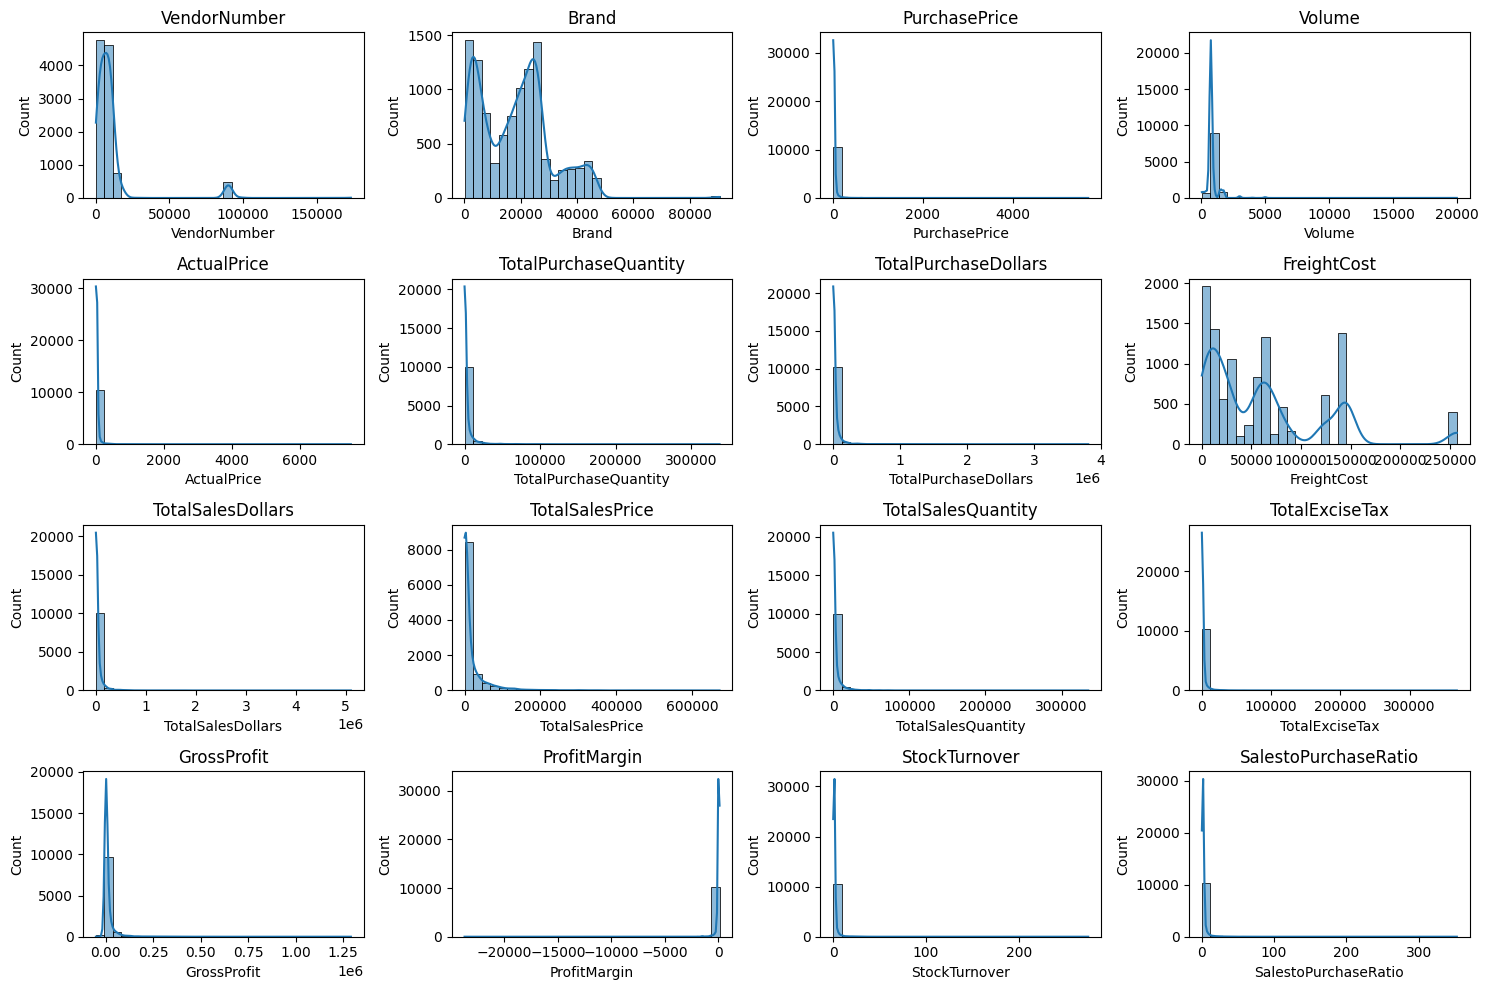

In [11]:
# Distribution columns for numeric valye 
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4,4,i+1) # adjust the grid layout 
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

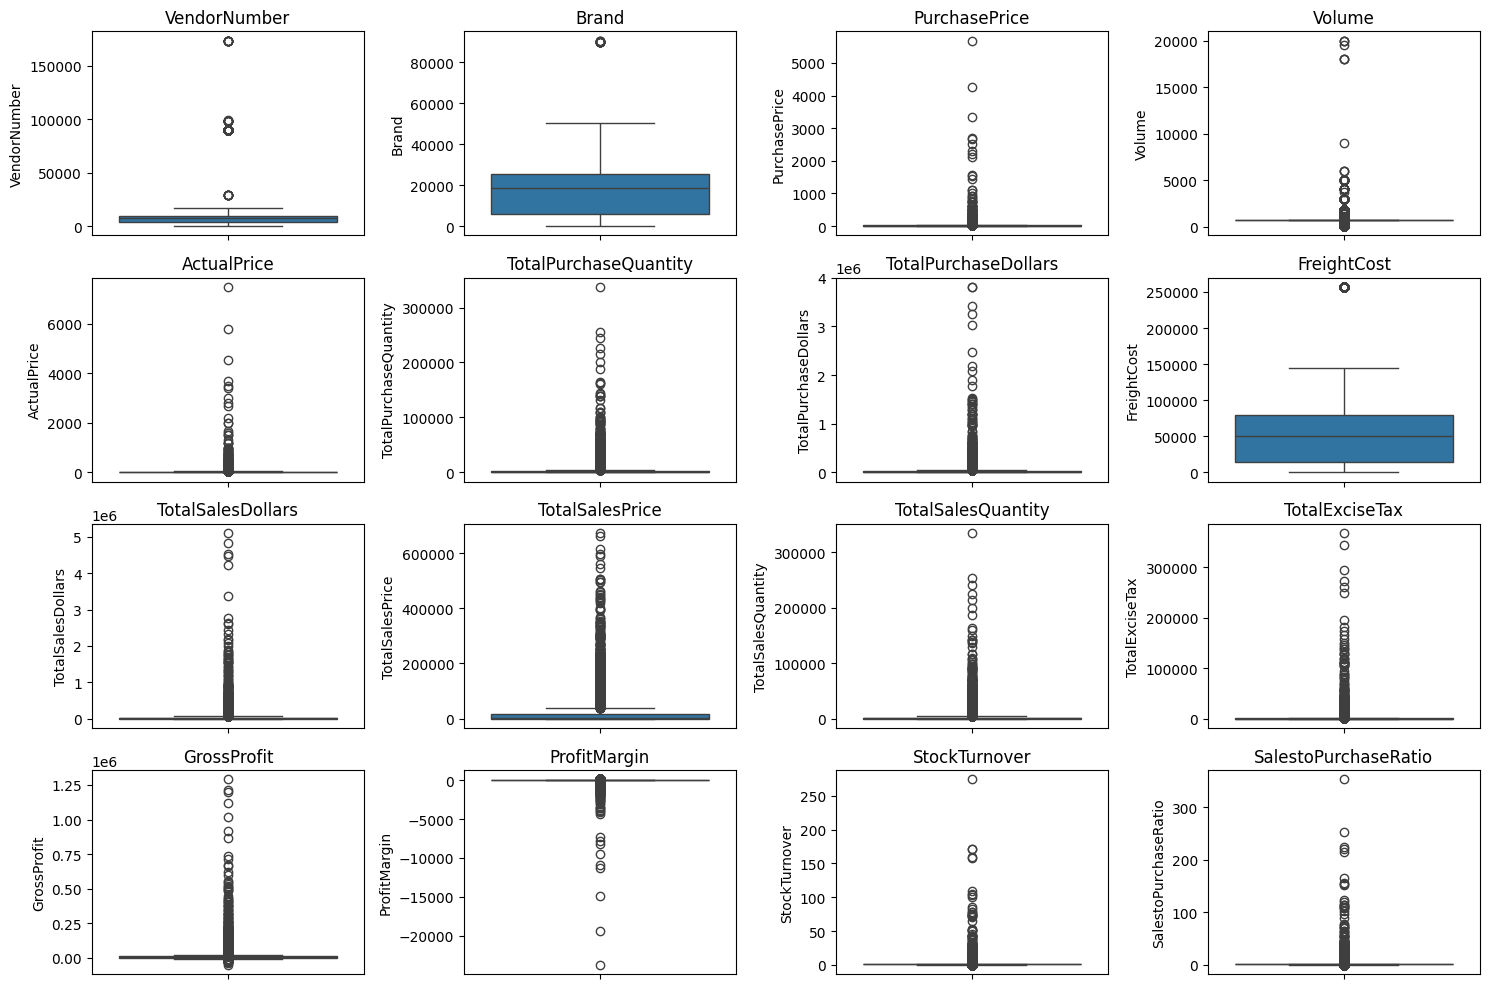

In [14]:
# Ouliers Detection for with boxplot 
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4,4,i+1) # adjust the grid layout 
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Summary Statistics Insights:
Negative & Zero Values:
- Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts
lower than the purchase price..
- Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
- Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete
stock.
### Outliers Indicated by High Standard Deviations:
- Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium
products.
- Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
- Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that
Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [17]:
# Let's filter the data by removing incosistencies 
df = pd.read_sql_query("""select * 
                       from vendor_sales_summary
                       where GrossProfit > 0 and ProfitMargin > 0 and TotalSalesQuantity > 0""", conn)

In [18]:
df

,VendorNumber,VendorName,Brand,PurchasePrice,Description,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,FreightCost,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,26.27,Jack Daniels No 7 Black,1750.0,36.99,145080,3811251.60,68601.68,5101919.51,672819.31,142049.0,260999.20,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,23.19,Tito's Handmade Vodka,1750.0,28.99,164038,3804041.22,144929.24,4819073.49,561512.37,160247.0,294438.66,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,18.24,Absolut 80 Proof,1750.0,24.99,187407,3418303.68,123780.22,4538120.60,461140.15,187140.0,343854.07,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,16.17,Capt Morgan Spiced Rum,1750.0,22.99,201682,3261197.94,257032.07,4475972.88,420050.01,200412.0,368242.80,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,21.89,Ketel One Vodka,1750.0,29.99,138109,3023206.01,257032.07,4223107.62,545778.28,135838.0,249587.83,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8536,9815,WINE GROUP INC,8527,1.32,Concannon Glen Ellen Wh Zin,750.0,4.99,2,2.64,27100.41,15.95,10.96,5.0,0.55,13.31,83.448276,2.500000,6.041667
8537,8004,SAZERAC CO INC,5683,0.39,Dr McGillicuddy's Apple Pie,50.0,0.49,6,2.34,50293.62,65.66,1.47,134.0,7.04,63.32,96.436186,22.333333,28.059829
8538,3924,HEAVEN HILL DISTILLERIES,9123,0.74,Deep Eddy Vodka,50.0,0.99,2,1.48,14069.87,1.98,0.99,2.0,0.10,0.50,25.252525,1.000000,1.337838
8539,3960,DIAGEO NORTH AMERICA INC,6127,1.47,The Club Strawbry Margarita,200.0,1.99,1,1.47,257032.07,143.28,77.61,72.0,15.12,141.81,98.974037,72.000000,97.469388


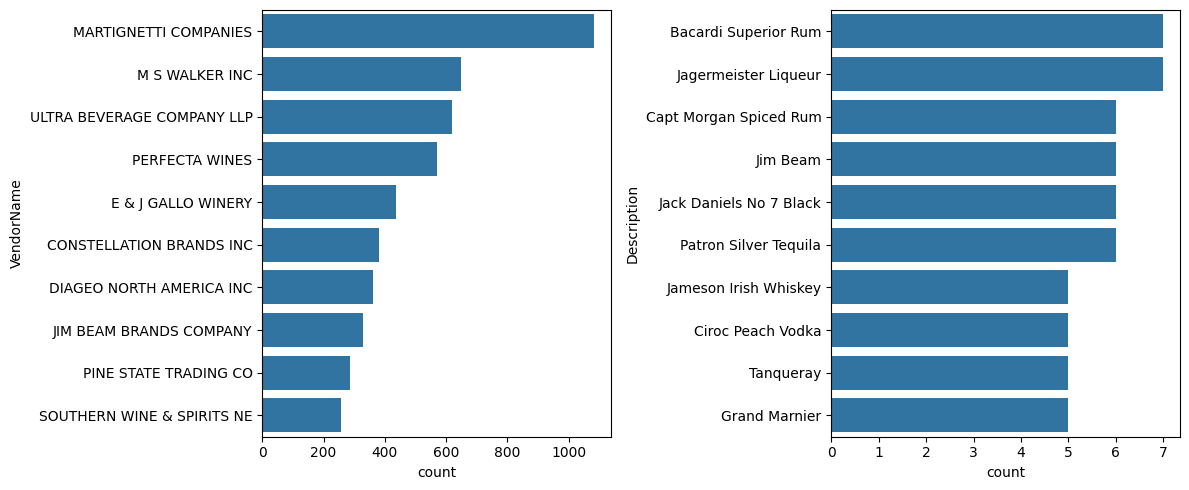

In [20]:
# count plot for categorical columns 
categorical_cols = ['VendorName','Description']
plt.figure(figsize=(12,5))
for i , col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(df[col], order=df[col].value_counts().index[:10]) # top 10 

plt.tight_layout()
plt.show()

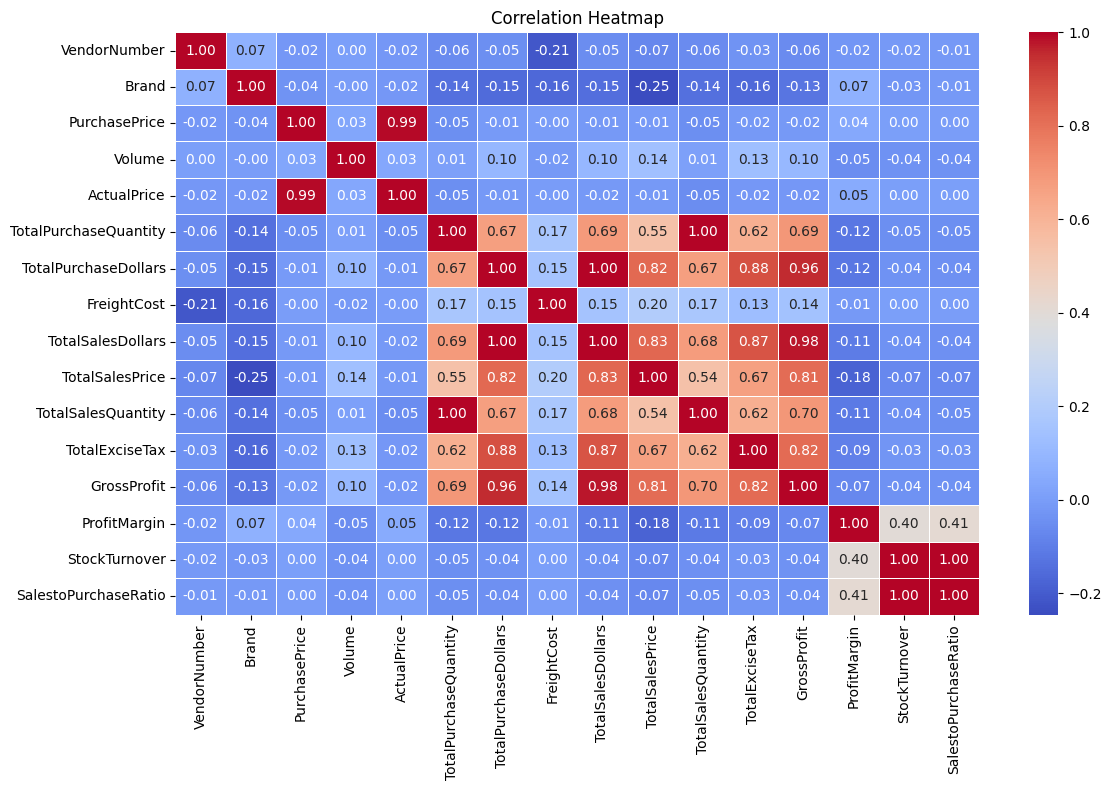

In [36]:
# Correlation heatmap
plt.figure(figsize=(12,8))  
numeric_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True , fmt='.2f', cmap='coolwarm',linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Correlation Insights
- PurchasePrice has weak correlations with TotalSales Dollars (-0.012) and Gross Profit (-0.016), suggesting that price variations do not significantly impact
sales revenue or profit.
- Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
- Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive
pricing pressures.
- Stock Turnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily
result in higher profitability.

# Data Analysis

Identfy Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margin. 

In [37]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars' : 'sum',
    'ProfitMargin' : 'mean'
}).reset_index()


In [42]:
low_sales_thresold = brand_performance['TotalSalesDollars'].quantile(0.15) 
high_margin_thresold = brand_performance['ProfitMargin'].quantile(0.85)

In [39]:
low_sales_thresold

np.float64(560.146)

In [43]:
high_margin_thresold 

np.float64(64.9299097086893)

In [45]:
# Filter brands with low sale but high profit margin
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars']<=low_sales_thresold)& 
    (brand_performance['ProfitMargin']>=high_margin_thresold) ]
print("Brands with low sales but high profit margin")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but high profit margin


,Description,TotalSalesDollars,ProfitMargin
6197,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6235,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5072,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6243,Sbragia Home Ranch Merlot,549.75,66.444748


In [60]:
# filter data for better visualization
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000]

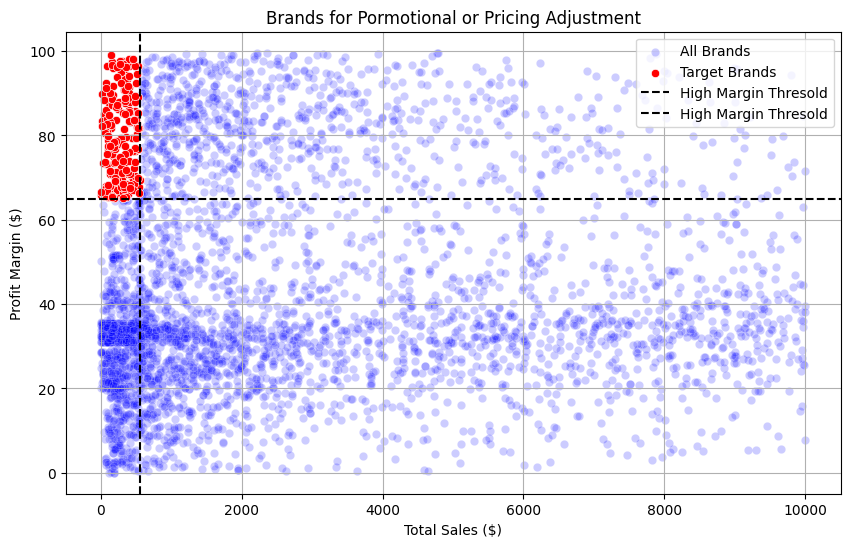

In [61]:
# Plot above data into scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin',color='blue',label='All Brands',alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin',color='red',label='Target Brands')

plt.axhline(high_margin_thresold, linestyle = '--', color='black',label='High Margin Thresold')
plt.axvline(low_sales_thresold, linestyle = '--', color='black',label='High Margin Thresold')

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin ($)')
plt.title('Brands for Pormotional or Pricing Adjustment')
plt.legend()
plt.grid(True)
plt.show()

### Which vendors and brands demonstrate the highest sales performance?

In [64]:
# format dollars 
def format_dollars(value):
    if value >=1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value>= 1_000 :
        return f"{value/1_000:.2f}K"
    return str(value)


In [66]:
top_vendors = df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands = df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16456111.43
M S WALKER INC                14679529.55
Name: TotalSalesDollars, dtype: float64

In [68]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [69]:
top_brands.apply(lambda x : format_dollars(x))


Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

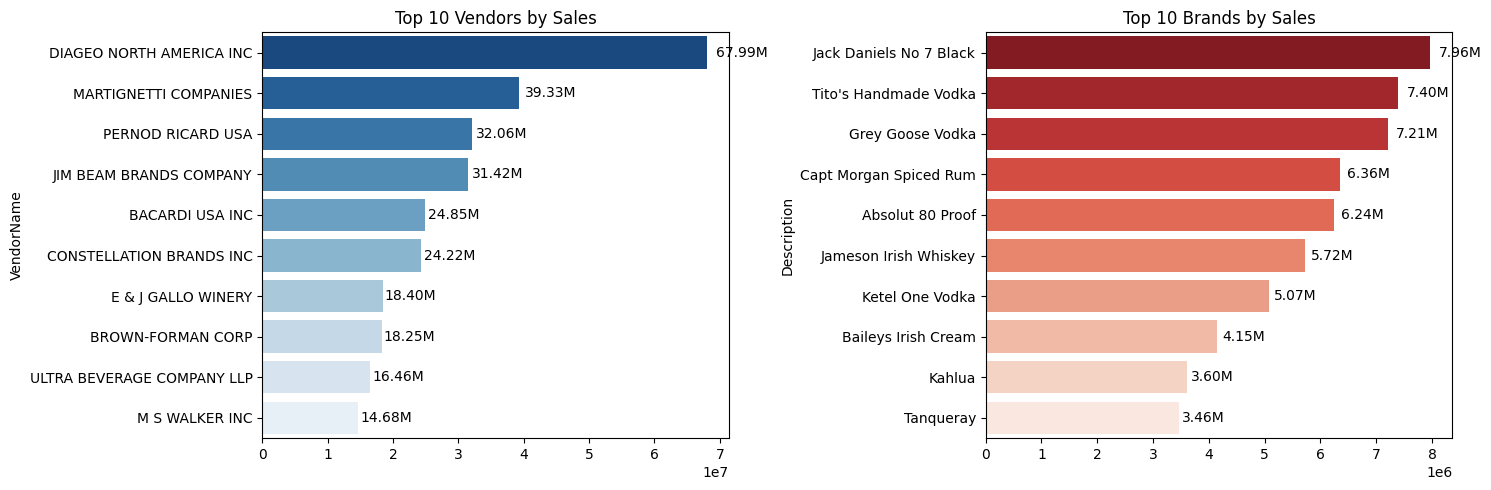

In [80]:
# Plot the Top Values on barplot
plt.figure(figsize=(15,5))
# Top vendors 
plt.subplot(1,2,1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette='Blues_r')
plt.title('Top 10 Vendors by Sales')
for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
    bar.get_y() + bar.get_height() / 2,
    format_dollars (bar.get_width()),
    ha='left', va='center', fontsize=10, color='black')


# Top vendors 
plt.subplot(1,2,2)
ax1 = sns.barplot(y=top_brands.index, x=top_brands.values, palette='Reds_r')
plt.title('Top 10 Brands by Sales')
for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
    bar.get_y() + bar.get_height() / 2,
    format_dollars (bar.get_width()),
    ha='left', va='center', fontsize=10, color='black')


plt.tight_layout()
plt.show()

## Which vendor contribute the most to total purchase dollars?

In [138]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars' : 'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...,...
113,WEIN BAUER INC,42694.64,13522.49,56217.13
114,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
115,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20
116,WINE GROUP INC,5203801.17,3100242.11,8304043.28


In [140]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/ vendor_performance['TotalPurchaseDollars'].sum()*100
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.34
56,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,8.32
67,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.78
45,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.66
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.69
...,...,...,...,...,...
43,"IRA GOLDMAN AND WILLIAMS, LLP",190.88,474.94,665.82,0.00
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.00
106,UNCORKED,118.74,58.20,176.94,0.00
84,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00


In [141]:
# format the dollars 
top_vendors = vendor_performance.head(10)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)

In [142]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.34
56,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.32
67,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.78
45,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.66
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.69
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.98
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.32
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.94
105,ULTRA BEVERAGE COMPANY LLP,11.13M,5.33M,16.46M,3.63
52,M S WALKER INC,9.75M,4.93M,14.68M,3.18


In [143]:
# total vendors 
vendor_performance.shape

(118, 5)

In [144]:
# cumulative sum
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.34,16.34
56,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.32,24.66
67,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.78,32.44
45,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.66,40.10
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.69,45.79
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.98,50.77
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.32,55.09
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.94,59.03
105,ULTRA BEVERAGE COMPANY LLP,11.13M,5.33M,16.46M,3.63,62.66
52,M S WALKER INC,9.75M,4.93M,14.68M,3.18,65.84


From above vendor_performance data show that top 10 vendor from 118 contribute 66%  

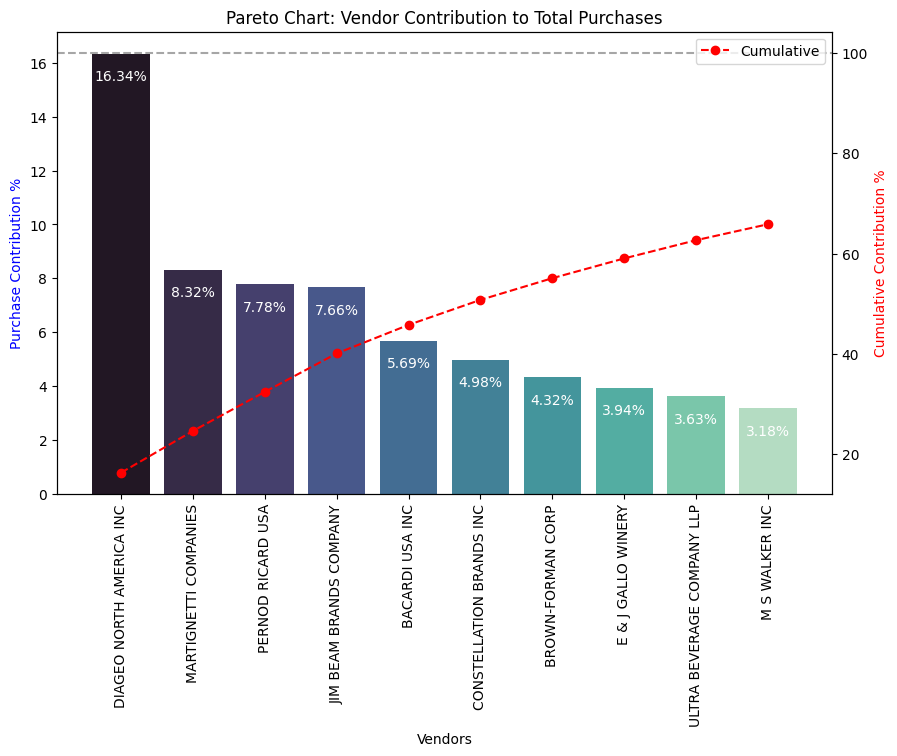

In [145]:
fig, ax1 = plt.subplots(figsize = (10,6))

# Bar Plot for puchase contribution 
sns.barplot(x=top_vendors['VendorName'],y=top_vendors['PurchaseContribution%'],palette='mako', ax = ax1 )
for i , value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value-1 , str(value)+'%',ha='center',fontsize=10,color='white')

# line chart for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'],top_vendors['Cumulative_Contribution%'], color='red',marker='o',linestyle='dashed',label='Cumulative')

ax1.set_xticklabels (top_vendors [ 'VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')
ax2.axhline (y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2. legend (loc='upper right')
plt.show()

In [148]:
print(f'Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %')

Total Purchase Contribution of top 10 vendors is 65.84 %


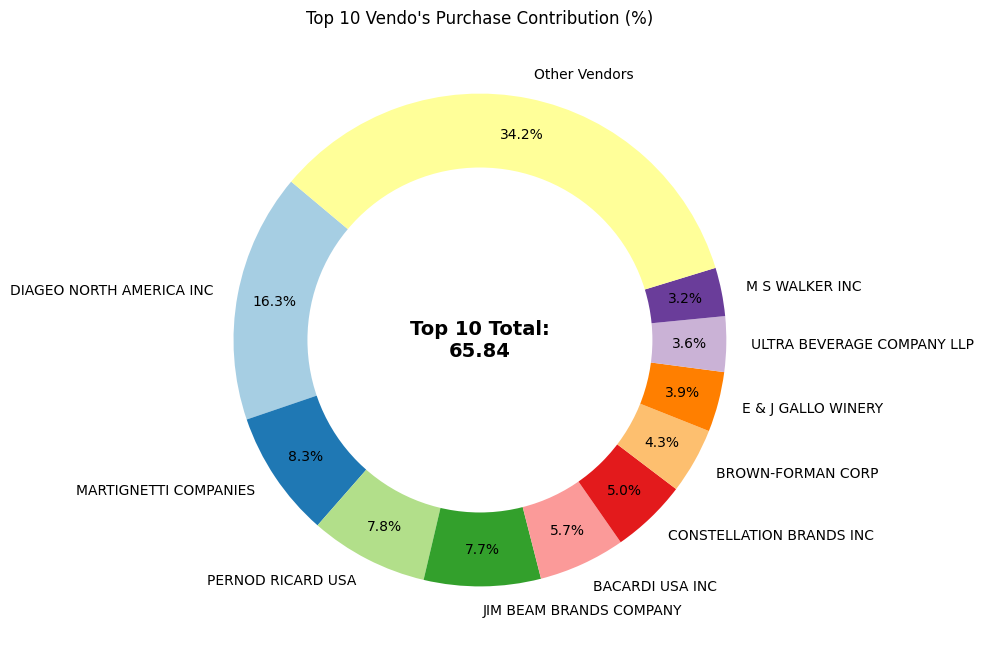

In [153]:
vendors = list(top_vendors['VendorName'].values)
purchase_contribution = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contribution)
remaning_contribution = 100 - total_contribution

# Append the others 
vendors.append('Other Vendors')
purchase_contribution.append(remaning_contribution)

# Donut chat    
fig, ax = plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax.pie(purchase_contribution,labels=vendors,autopct='%1.1f%%', startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)


# Draw a white circle in the center to create a "donut" effect
center_circle = plt.Circle((0,0),0.70, fc='white')
fig.gca().add_artist(center_circle)

# add total Contribution annotation in the center
plt.text(0,0, f"Top 10 Total:\n{total_contribution:.2f}",fontsize=14,fontweight='bold',ha='center',va='center')
plt.title("Top 10 Vendo's Purchase Contribution (%)")
plt.show()

### Does purchase in bulk reduce the unit price, and what is the optimal purchase volume for cost savings? 

In [167]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars']/ df['TotalPurchaseQuantity']


In [168]:
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'],q=3, labels=['Small','Medium','Large'])

In [169]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
8536,Small,2
8537,Small,6
8538,Small,2
8539,Small,1


In [171]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.128653
Medium,15.489374
Large,10.776200


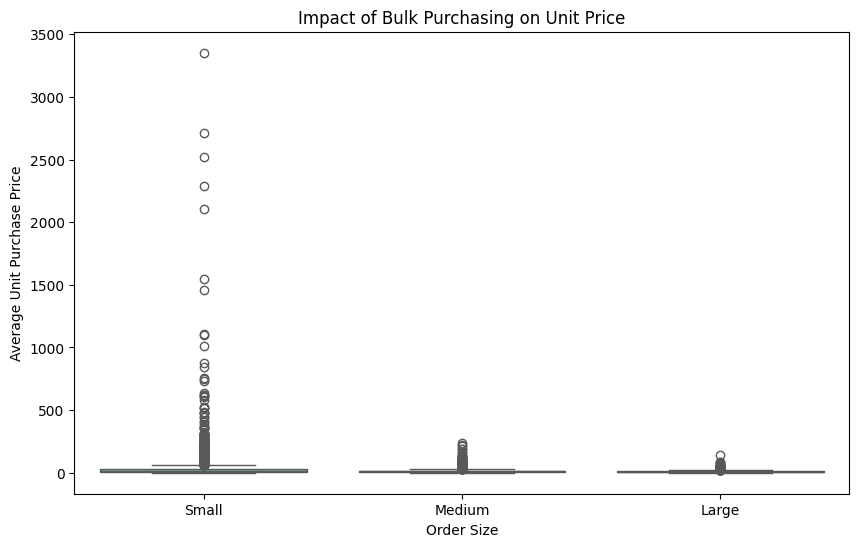

In [178]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='OrderSize',y='UnitPurchasePrice',palette='Set2')
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

- Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
- The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
- This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit
revenue.

### Which vendor have low inventory turnover, indicating excess stock and slow-moving product?

In [185]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values(by='StockTurnover').head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


### How much capital is locked in unsold inventory per vendor, and which vendors contribute the most it to?

In [187]:
df['UnsoldInventoryValue'] = (df['TotalPurchaseQuantity']-df['TotalSalesQuantity'])* df['PurchasePrice']
print("Total Usold Capiltal: ",format_dollars(df['UnsoldInventoryValue'].sum()))


Total Usold Capiltal:  2.69M


In [191]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby('VendorName')['UnsoldInventoryValue'].sum().reset_index()

# Sort Vendor with the highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values (by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head (10)


,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
45,JIM BEAM BRANDS COMPANY,554.67K
67,PERNOD RICARD USA,470.63K
115,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
11,BROWN-FORMAN CORP,177.73K
78,SAZERAC CO INC,173.03K
20,CONSTELLATION BRANDS INC,133.62K
60,MOET HENNESSY USA INC,126.48K
76,REMY COINTREAU USA INC,118.60K


### What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.

In [192]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

In [193]:
top_vendors = df [df ["TotalSalesDollars"] >= top_threshold] ["ProfitMargin"].dropna()
low_vendors = df [df ["TotalSalesDollars"] <= low_threshold] ["ProfitMargin"].dropna ()

In [195]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3509    79.684817
3667    85.782102
4736    93.085860
4905    95.012530
5035    94.271857
Name: ProfitMargin, Length: 2136, dtype: float64

In [200]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data,ddof=1) / np.sqrt(len(data))
    t_critical = stats.t.ppf((1+confidence)/2, df=len(data)-1)
    margin_of_err = t_critical* std_err
    return mean_val,mean_val-margin_of_err, mean_val+margin_of_err  

Top Vendors 95% CI: ( 30.73,  31.60), Mean: 31.17
Low Vendors 95% CI: (40.46,  42.60), Mean:  41.53


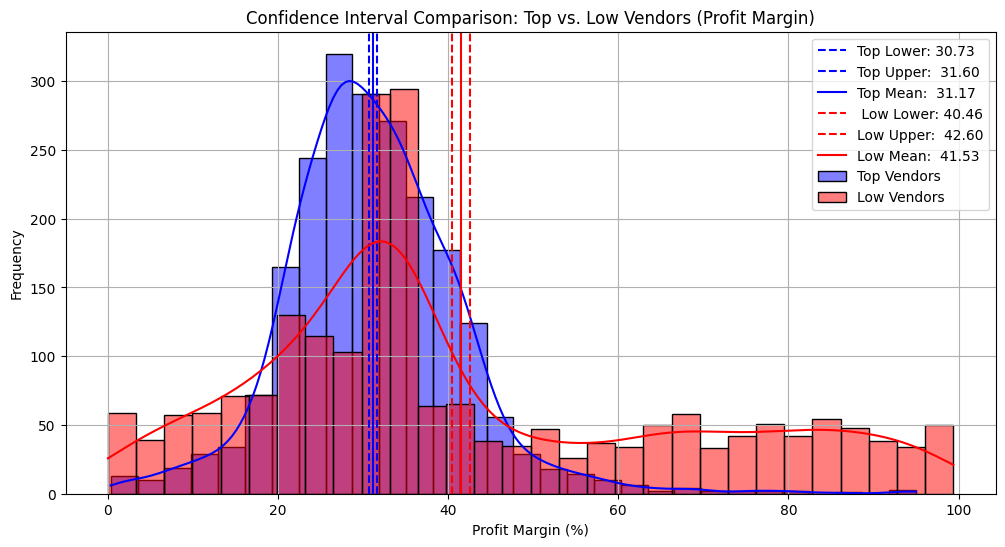

In [201]:
top_mean, top_lower , top_upper = confidence_interval(top_vendors)
low_mean, low_lower , low_upper = confidence_interval(low_vendors)

print (f"Top Vendors 95% CI: ({top_lower: .2f}, {top_upper: .2f}), Mean: {top_mean:.2f}")
print (f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper: .2f}), Mean: {low_mean: .2f}")
plt.figure(figsize=(12, 6))
# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline (top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline (top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper: .2f}")
plt.axvline (top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean: .2f}")
# Low Vendors Plot
sns.histplot (low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline (low_lower, color="red", linestyle="--", label=f" Low Lower: {low_lower:.2f}")
plt.axvline (low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper: .2f}")
plt.axvline (low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean: .2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt. legend()
plt.grid(True)
plt.show()

- The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
- For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved
distribution strategies.